In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
print("Environment Ready")

Environment Ready


In [3]:
trades = pd.read_csv("../data/historical_data.csv")
sentiment = pd.read_csv("../data/fear_greed_index.csv")
print("Trades Shape:", trades.shape)
print("Sentiment Shape:", sentiment.shape)

Trades Shape: (211224, 16)
Sentiment Shape: (2644, 4)


In [4]:
print("TRADES COLUMNS")
print(trades.columns)
print("\nSENTIMENT COLUMNS")
print(sentiment.columns)

TRADES COLUMNS
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')

SENTIMENT COLUMNS
Index(['timestamp', 'value', 'classification', 'date'], dtype='str')


In [5]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [6]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [7]:
print("TRADES MISSING VALUES")
print(trades.isnull().sum())

print("\nSENTIMENT MISSING VALUES")
print(sentiment.isnull().sum())

TRADES MISSING VALUES
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

SENTIMENT MISSING VALUES
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [8]:
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    dayfirst=True
)

trades["trade_date"] = trades["Timestamp IST"].dt.date

trades[["Timestamp IST", "trade_date"]].head()

,Timestamp IST,trade_date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [9]:
sentiment["date"] = pd.to_datetime(
    sentiment["date"]
)

sentiment["trade_date"] = sentiment["date"].dt.date

sentiment[["date", "trade_date"]].head()

,date,trade_date
0,2018-02-01,2018-02-01
1,2018-02-02,2018-02-02
2,2018-02-03,2018-02-03
3,2018-02-04,2018-02-04
4,2018-02-05,2018-02-05


In [10]:
merged = pd.merge(
    trades,
    sentiment[["trade_date", "classification", "value"]],
    on="trade_date",
    how="left"
)

print("Merged Shape:", merged.shape)

Merged Shape: (211224, 19)


In [11]:
merged[
    [
        "trade_date",
        "Closed PnL",
        "Direction",
        "classification",
        "value"
    ]
].head()

,trade_date,Closed PnL,Direction,classification,value
0,2024-12-02,0.0,Buy,Extreme Greed,80.0
1,2024-12-02,0.0,Buy,Extreme Greed,80.0
2,2024-12-02,0.0,Buy,Extreme Greed,80.0
3,2024-12-02,0.0,Buy,Extreme Greed,80.0
4,2024-12-02,0.0,Buy,Extreme Greed,80.0


In [12]:
merged["profitable"] = merged["Closed PnL"] > 0

merged["trade_size_usd"] = merged["Size USD"]

merged["absolute_pnl"] = merged["Closed PnL"].abs()

In [13]:
merged[
    [
        "Closed PnL",
        "profitable",
        "trade_size_usd"
    ]
].head()

,Closed PnL,profitable,trade_size_usd
0,0.0,False,7872.16
1,0.0,False,127.68
2,0.0,False,1150.63
3,0.0,False,1142.04
4,0.0,False,69.75


In [14]:
avg_pnl = (
    merged
    .groupby("classification")["Closed PnL"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_pnl)

classification
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Extreme Fear     34.537862
Neutral          34.307718
Name: Closed PnL, dtype: float64


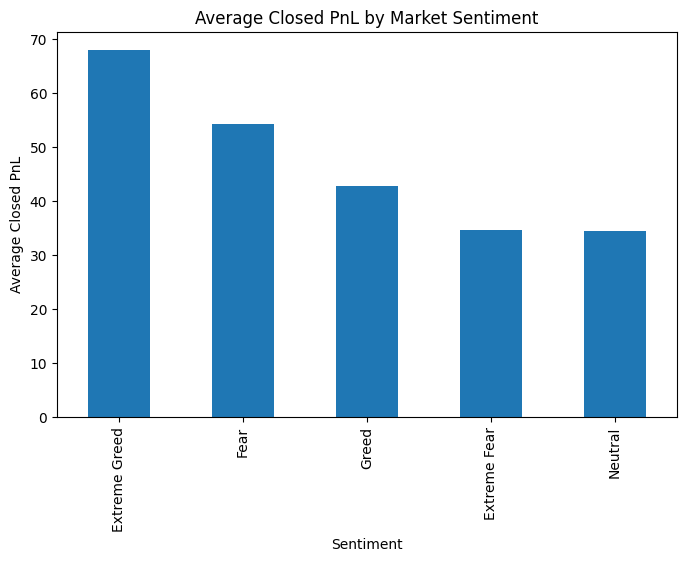

In [15]:
plt.figure(figsize=(8,5))

avg_pnl.plot(kind="bar")

plt.title("Average Closed PnL by Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xlabel("Sentiment")

plt.show()

In [16]:
print(avg_pnl)

classification
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Extreme Fear     34.537862
Neutral          34.307718
Name: Closed PnL, dtype: float64


classification
Extreme Greed    46.494299
Fear             42.076750
Neutral          39.699093
Greed            38.482794
Extreme Fear     37.060748
Name: profitable, dtype: float64


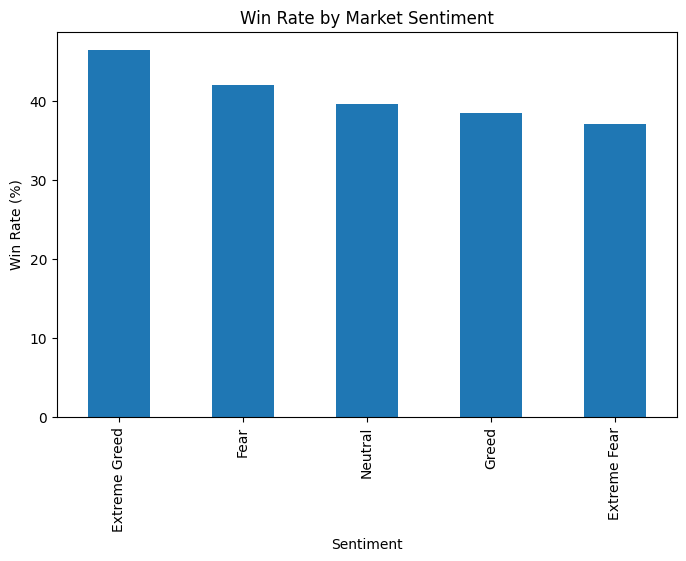

In [17]:
win_rate = (
    merged
    .groupby("classification")["profitable"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(win_rate)
plt.figure(figsize=(8,5))

win_rate.plot(kind="bar")

plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.xlabel("Sentiment")

plt.show()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
dtype: int64


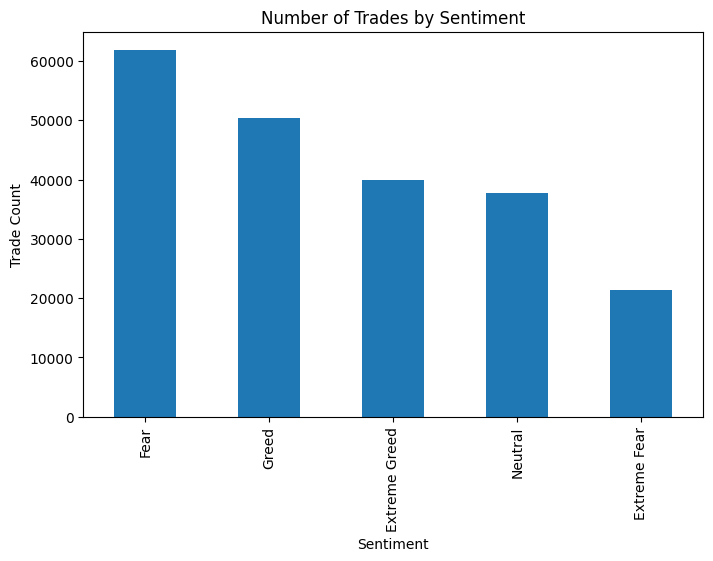

In [18]:
trade_count = (
    merged
    .groupby("classification")
    .size()
    .sort_values(ascending=False)
)

print(trade_count)
plt.figure(figsize=(8,5))

trade_count.plot(kind="bar")

plt.title("Number of Trades by Sentiment")
plt.ylabel("Trade Count")
plt.xlabel("Sentiment")

plt.show()

classification
Fear             7816.109931
Greed            5736.884375
Extreme Fear     5349.731843
Neutral          4782.732661
Extreme Greed    3112.251565
Name: trade_size_usd, dtype: float64


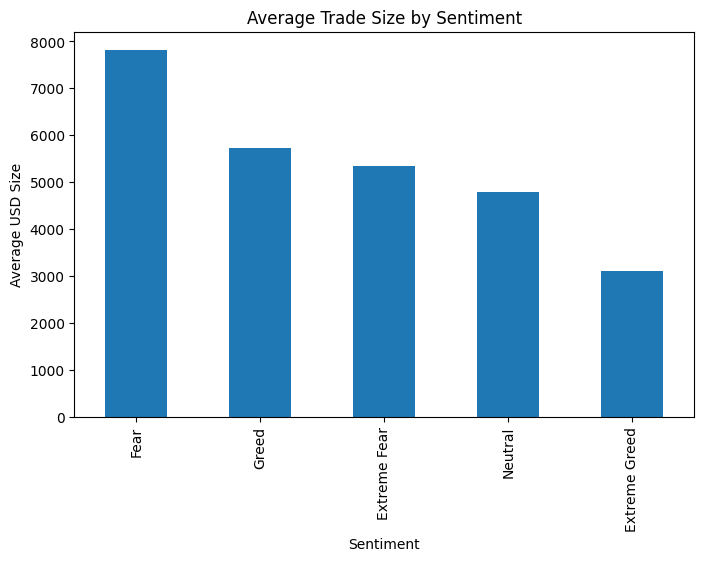

In [19]:
avg_size = (
    merged
    .groupby("classification")["trade_size_usd"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_size)
plt.figure(figsize=(8,5))

avg_size.plot(kind="bar")

plt.title("Average Trade Size by Sentiment")
plt.ylabel("Average USD Size")
plt.xlabel("Sentiment")

plt.show()

In [20]:
direction_analysis = pd.crosstab(
    merged["classification"],
    merged["Direction"]
)

print(direction_analysis)

Direction       Auto-Deleveraging   Buy  Close Long  Close Short  \
classification                                                     
Extreme Fear                    0   807        6241         3117   
Extreme Greed                   0  5132        7186         6497   
Fear                            0  3207       17260         9221   
Greed                           8  4685        7998        11322   
Neutral                         0  2885        9993         5850   

Direction       Liquidated Isolated Short  Long > Short  Open Long  \
classification                                                       
Extreme Fear                            0             5       7005   
Extreme Greed                           0             7       6300   
Fear                                    0            14      17824   
Greed                                   1            16       8544   
Neutral                                 0            15      10222   

Direction       Open Short  Sell

In [21]:
top_traders = (
    merged
    .groupby("Account")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
)
print(top_traders.head(10))
top_accounts = top_traders.head(10).index

elite = merged[
    merged["Account"].isin(top_accounts)
]

elite.groupby("classification")["Closed PnL"].mean()


Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64


classification
Extreme Fear      60.765008
Extreme Greed    136.960455
Fear              66.979192
Greed             93.526109
Neutral           53.831636
Name: Closed PnL, dtype: float64

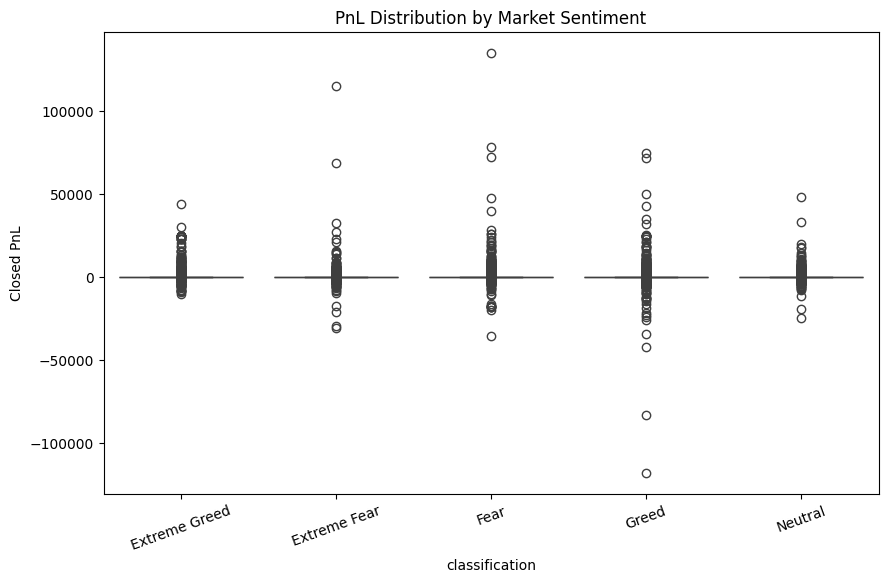

In [22]:
sentiment_summary = (
    merged
    .groupby("classification")
    .agg(
        avg_pnl=("Closed PnL", "mean"),
        median_pnl=("Closed PnL", "median"),
        total_pnl=("Closed PnL", "sum"),
        win_rate=("profitable", "mean"),
        avg_trade_size=("trade_size_usd", "mean"),
        trade_count=("Closed PnL", "count")
    )
)

sentiment_summary["win_rate"] *= 100

sentiment_summary.sort_values(
    by="total_pnl",
    ascending=False
)
plt.figure(figsize=(10,6))

sns.boxplot(
    data=merged,
    x="classification",
    y="Closed PnL"
)

plt.title("PnL Distribution by Market Sentiment")
plt.xticks(rotation=20)

plt.show()